In [ ]:
!git clone https://github.com/SJTU-YONGFU-RESEARCH-GRP/Parkinson-Patient-Speech-Dataset.git



fatal: destination path 'Parkinson-Patient-Speech-Dataset' already exists and is not an empty directory.


In [ ]:
!ls Parkinson-Patient-Speech-Dataset


denoised-speech-dataset  original-speech-dataset  pic  README.md  speech


In [ ]:
!pip install librosa


In [ ]:
import librosa
import numpy as np
import os
import pandas as pd
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=3)

    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)
    contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr), axis=1)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))

    return np.hstack([mfcc, chroma, contrast, zcr])


In [ ]:
!ls



final_parkinson_dataset_20k.csv   parkinsons.data
Parkinson-Patient-Speech-Dataset  sample_data
parkinsons_audio_features.csv	  telemonitoring_parkinsons_updrs.data.csv


In [ ]:
!ls Parkinson-Patient-Speech-Dataset


denoised-speech-dataset  original-speech-dataset  pic  README.md  speech


In [ ]:
!ls Parkinson-Patient-Speech-Dataset/Dataset


ls: cannot access 'Parkinson-Patient-Speech-Dataset/Dataset': No such file or directory


In [ ]:
!find Parkinson-Patient-Speech-Dataset -name "*.wav" | head


Parkinson-Patient-Speech-Dataset/original-speech-dataset/DL/DL2.wav
Parkinson-Patient-Speech-Dataset/original-speech-dataset/DL/DL60.wav
Parkinson-Patient-Speech-Dataset/original-speech-dataset/DL/DL56.wav
Parkinson-Patient-Speech-Dataset/original-speech-dataset/DL/DL28.wav
Parkinson-Patient-Speech-Dataset/original-speech-dataset/DL/DL16.wav
Parkinson-Patient-Speech-Dataset/original-speech-dataset/DL/DL34.wav
Parkinson-Patient-Speech-Dataset/original-speech-dataset/DL/DL39.wav
Parkinson-Patient-Speech-Dataset/original-speech-dataset/DL/DL64.wav
Parkinson-Patient-Speech-Dataset/original-speech-dataset/DL/DL3.wav
Parkinson-Patient-Speech-Dataset/original-speech-dataset/DL/DL17.wav


In [ ]:
base_path = "Parkinson-Patient-Speech-Dataset/Data"


In [ ]:
base_path = "Parkinson-Patient-Speech-Dataset/dataset"


In [ ]:
base_path = "Parkinson-Patient-Speech-Dataset"


In [ ]:
import os

data = []
labels = []

base_repo = "Parkinson-Patient-Speech-Dataset"

for root, dirs, files in os.walk(base_repo):
    for file in files:
        if file.lower().endswith(".wav"):
            file_path = os.path.join(root, file)

            # Label based on folder name
            if "PD" in root or "Parkinson" in root:
                label = 1
            elif "HC" in root or "Healthy" in root:
                label = 0
            else:
                continue

            features = extract_features(file_path)
            data.append(features)
            labels.append(label)


In [ ]:
#coverting The Github speech dataset into CSV
print("Total samples extracted:", len(data))
print("Parkinson samples:", sum(labels))
print("Healthy samples:", len(labels) - sum(labels))


Total samples extracted: 1160
Parkinson samples: 1160
Healthy samples: 0


In [ ]:
#Converting the github file into csv
print(len(data[0]))
feature_columns = (
    [f"mfcc_{i}" for i in range(13)] +
    [f"chroma_{i}" for i in range(12)] +
    [f"contrast_{i}" for i in range(7)] +
    ["zcr"]
)
import pandas as pd

df_audio = pd.DataFrame(data, columns=feature_columns)
df_audio["label"] = labels   # 1 = Parkinson, 0 = Healthy
df_audio.head()


33


,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,...,chroma_11,contrast_0,contrast_1,contrast_2,contrast_3,contrast_4,contrast_5,contrast_6,zcr,label
0,-435.806488,100.213646,-19.618366,36.520916,-7.553804,22.405487,-8.348460,12.438696,-3.465434,1.501570,...,0.199365,19.333309,16.940711,17.077837,14.991005,16.547634,15.912053,47.508296,0.065899,1
1,-412.907959,80.940201,-14.530183,31.908381,-14.702774,18.749826,-9.853261,9.408290,-13.252960,-2.386656,...,0.385015,19.625972,13.464406,14.663626,14.053123,14.999352,15.179763,49.203117,0.094054,1
2,-448.904388,90.365387,-22.372152,34.165653,-10.381683,19.207155,-11.505992,1.575755,-6.980103,-1.684511,...,0.345049,17.703733,11.631010,13.874254,13.515675,14.565764,14.962791,46.000226,0.072544,1
3,-482.008667,77.656868,-27.031664,42.686409,-23.250170,22.403872,-21.618818,-1.822729,-17.301510,-0.416126,...,0.303082,17.699459,12.111682,14.274323,13.452556,14.628025,14.366177,48.966227,0.101202,1
4,-412.877380,73.946518,-27.003084,33.359951,-23.059343,18.057037,-17.850876,0.368357,-11.721468,-3.355936,...,0.314605,20.259240,14.220334,15.844517,14.308630,15.421675,16.012421,50.452640,0.107565,1


In [ ]:
print("Dataset shape:", df_audio.shape)
df_audio.to_csv("parkinsons_audio_features.csv", index=False)
from google.colab import files
files.download("parkinsons_audio_features.csv")



Dataset shape: (1160, 34)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE


In [ ]:
#Start the merging
import pandas as pd
import numpy as np
# Load datasets
df1 = pd.read_csv("/content/parkinsons.data")              # UCI Parkinson dataset
df2 = pd.read_csv("/content/telemonitoring_parkinsons_updrs.data.csv")
df3 = pd.read_csv("/content/parkinsons_audio_features.csv")


In [ ]:
print(df1.columns)
print(df2.columns)
print(df3.columns)


Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')
Index(['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS',
       'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
       'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE'],
      dtype='object')
Index(['mfcc_0', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6',
       'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12',
       'chroma_0', 'chroma_1', 'chroma_2', 'chroma_3', 'chroma_4', 'chroma_5',
       'chroma_6', 'chroma_7', 'chroma_8', 'chroma_9', 'chroma_10',
       'chroma_11', 'contrast_0

In [ ]:
print(df2.head())
print(df2.columns)
df2["label"] = 1   # 1 = Parkinson
df2["label"] = 0   # 0 = Healthy



   subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  Jitter(%)  \
0         1   72    0     5.6431       28.199       34.398    0.00662   
1         1   72    0    12.6660       28.447       34.894    0.00300   
2         1   72    0    19.6810       28.695       35.389    0.00481   
3         1   72    0    25.6470       28.905       35.810    0.00528   
4         1   72    0    33.6420       29.187       36.375    0.00335   

   Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  ...  Shimmer(dB)  Shimmer:APQ3  \
0     0.000034     0.00401      0.00317  ...        0.230       0.01438   
1     0.000017     0.00132      0.00150  ...        0.179       0.00994   
2     0.000025     0.00205      0.00208  ...        0.181       0.00734   
3     0.000027     0.00191      0.00264  ...        0.327       0.01106   
4     0.000020     0.00093      0.00130  ...        0.176       0.00679   

   Shimmer:APQ5  Shimmer:APQ11  Shimmer:DDA       NHR     HNR     RPDE  \
0       0.01309        0.01662      

In [ ]:
df2["label"] = 1   # 1 = Parkinson
df2["label"] = 0   # 0 = Healthy
df2.head()


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE,label
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006,0
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810,0
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014,0
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277,0
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361,0


In [ ]:
def ensure_label_column(df, default_label=None):
    possible_labels = ["status", "label", "class", "diagnosis", "PD"]

    for col in possible_labels:
        if col in df.columns:
            df = df.rename(columns={col: "label"})
            return df

    if default_label is not None:
        df["label"] = default_label
        return df

    raise ValueError("No label column found and no default label provided!")


In [ ]:
df1 = ensure_label_column(df1)            # has label
df2 = ensure_label_column(df2, 1)         # PD-only dataset
df3 = ensure_label_column(df3)            # has label


In [ ]:
def rename_label_column(df):
    possible_labels = ["status", "label", "class", "diagnosis", "PD"]

    for col in possible_labels:
        if col in df.columns:
            df = df.rename(columns={col: "label"})
            return df

    raise ValueError("No label column found!")

df1 = rename_label_column(df1)
df2 = rename_label_column(df2)
df3 = rename_label_column(df3)


In [ ]:
# Find common feature columns (excluding label)
common_features = list(
    set(df1.columns) &
    set(df2.columns) &
    set(df3.columns)
)

# Remove label if present
common_features.remove("label")

print("Common Features:", len(common_features))


Common Features: 0


In [ ]:

# Merge datasets
merged_df = pd.concat([df1, df2, df3], axis=0, ignore_index=True)

print("Merged Dataset Shape:", merged_df.shape)


Merged Dataset Shape: (7230, 70)


In [ ]:
#SEPARATE FEATURES AND LABEL
X = merged_df.drop(columns=["label"])
y = merged_df["label"]


In [ ]:
# Separate features and label
X = merged_df.drop(columns=["name", "label"])  # drop ID + target
y = merged_df["label"]

#Apply imputer
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

#Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)


In [ ]:
#CHECK CLASS DISTRIBUTION
import numpy as np

unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))
#APPLY SMOTE (CLASS BALANCING)
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy="auto",
    k_neighbors=5,
    random_state=42
)

X_smote, y_smote = smote.fit_resample(X, y)

print("After SMOTE:", X_smote.shape)



{np.int64(0): np.int64(5923), np.int64(1): np.int64(1307)}
After SMOTE: (11846, 68)


In [ ]:
#GAUSSIAN NOISE AUGMENTATION
def gaussian_noise_augmentation(X, noise_std=0.01):
    noise = np.random.normal(
        loc=0.0,
        scale=noise_std,
        size=X.shape
    )
    return X + noise

X_noise = gaussian_noise_augmentation(X_smote)
y_noise = y_smote.copy()
#CREATE FINAL LARGE DATASET
X_final = np.vstack([X_smote, X_noise])
y_final = np.hstack([y_smote, y_noise])

print("Final Dataset Shape:", X_final.shape)


Final Dataset Shape: (23692, 68)


In [ ]:
#CONVERT TO FINAL CSV
final_df = pd.DataFrame(X_final, columns=merged_df.drop(columns=["name", "label"]).columns)
final_df["label"] = y_final

final_df.to_csv("final_parkinson_dataset_20k.csv", index=False)

In [ ]:
#EDA
#BASIC DATA OVERVIEW
print("Shape:", merged_df.shape)
merged_df.head()


Shape: (7230, 70)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,chroma_10,chroma_11,contrast_0,contrast_1,contrast_2,contrast_3,contrast_4,contrast_5,contrast_6,zcr
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#DATA TYPES & MISSING VALUES
merged_df.info()
merged_df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7230 entries, 0 to 7229
Data columns (total 70 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        6070 non-null   float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      6070 non-null   float64
 12  Shimmer:APQ5      6070 non-null   float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       6070 non-null   float64
 15  NHR               6070 non-null   float64
 16  HNR               6070 non-null   float64


,0
name,7035
MDVP:Fo(Hz),7035
MDVP:Fhi(Hz),7035
MDVP:Flo(Hz),7035
MDVP:Jitter(%),7035
...,...
contrast_3,6070
contrast_4,6070
contrast_5,6070
contrast_6,6070


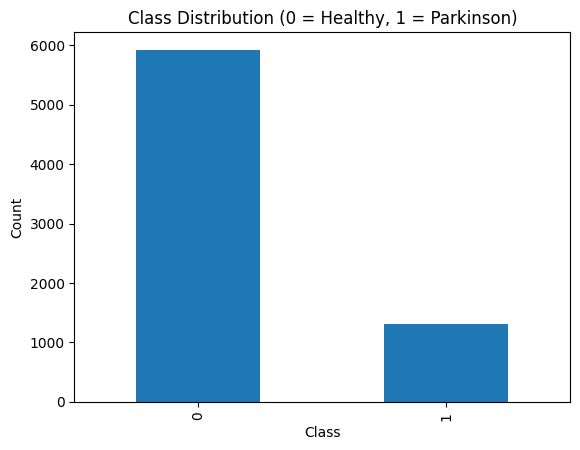

In [ ]:
#Data Distribution
import matplotlib.pyplot as plt

merged_df["label"].value_counts().plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution (0 = Healthy, 1 = Parkinson)")
plt.show()


In [ ]:
merged_df.describe()


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,chroma_10,chroma_11,contrast_0,contrast_1,contrast_2,contrast_3,contrast_4,contrast_5,contrast_6,zcr
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,6070.000000,195.000000,195.000000,...,1160.000000,1160.000000,1160.000000,1160.000000,1160.000000,1160.000000,1160.000000,1160.000000,1160.000000,1160.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.008992,0.029709,0.282251,...,0.243202,0.215584,21.251144,17.788100,18.719089,17.300234,18.137429,18.805133,48.534891,0.080296
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.009358,0.018857,0.194877,...,0.096295,0.093111,3.448696,2.647480,2.219721,1.816130,1.998979,2.497920,4.528898,0.037248
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.000980,0.009540,0.085000,...,0.050438,0.050681,12.714488,11.523005,13.608437,13.144355,13.208497,14.152002,16.924654,0.022810
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004740,0.016505,0.148500,...,0.178144,0.150697,19.000870,15.832755,17.060425,16.054811,16.702966,17.221907,46.982868,0.054327
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.006760,0.022970,0.221000,...,0.228680,0.198939,20.904404,17.664383,18.634709,17.177869,17.857929,18.658343,49.602263,0.072658
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.009930,0.037885,0.350000,...,0.290627,0.267579,23.239132,19.634837,20.202076,18.400781,19.286858,20.322170,51.186533,0.096066
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.172630,0.119080,1.302000,...,0.680223,0.701616,33.222365,26.211202,25.748225,24.548273,25.009697,68.658168,65.900885,0.281314


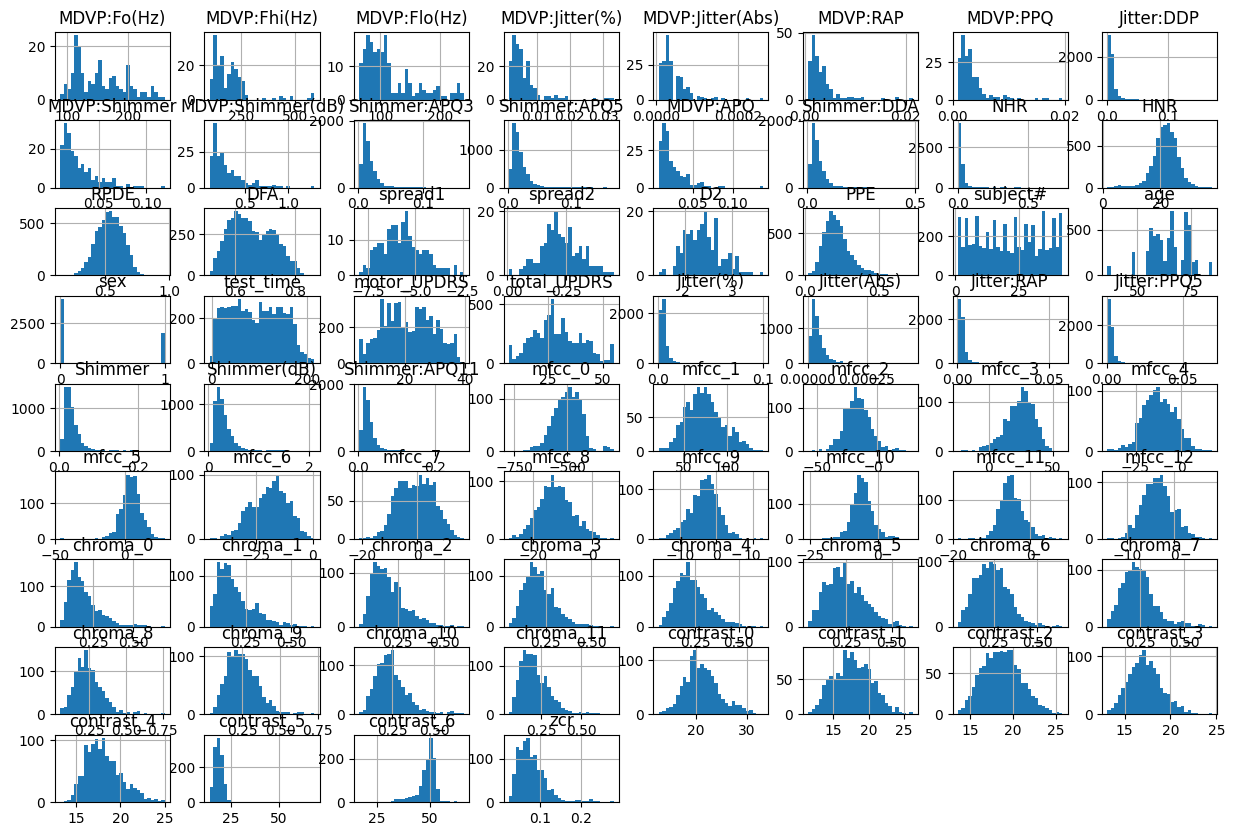

In [ ]:
#FEATURE DISTRIBUTION (SKewness Insight)
merged_df.drop(columns=["label"]).hist(
    figsize=(15, 10),
    bins=30
)
plt.show()


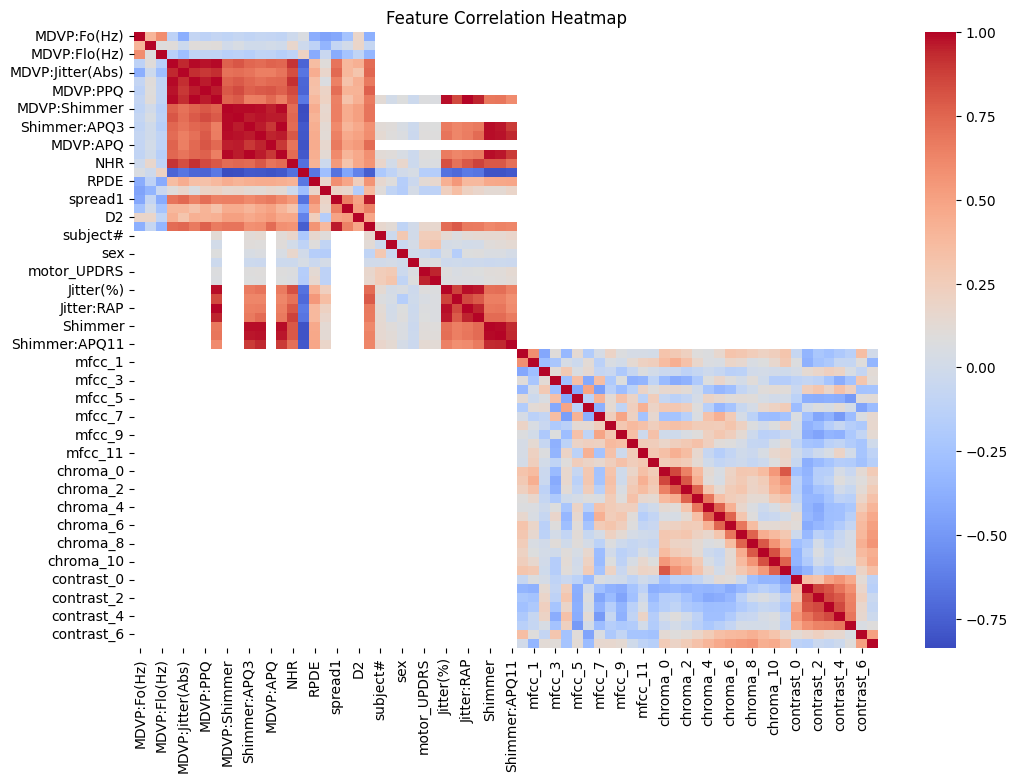

In [ ]:
#CORRELATION ANALYSIS
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(
    merged_df.drop(columns=["name", "label"]).corr(),
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
#Class Wise Feature Comparision
pd_features = merged_df[merged_df["label"] == 1]
hc_features = merged_df[merged_df["label"] == 0]

# Drop non-numeric columns like 'name' before calculating mean
(pd_features.drop(columns=["name"]).mean() - hc_features.drop(columns=["name"]).mean())

,0
MDVP:Fo(Hz),-36.757009
MDVP:Fhi(Hz),-35.195287
MDVP:Flo(Hz),-38.313734
MDVP:Jitter(%),0.003123
MDVP:Jitter(Abs),0.000027
...,...
contrast_3,NaN
contrast_4,NaN
contrast_5,NaN
contrast_6,NaN


In [ ]:
import numpy as np
import pandas as pd
X_final = np.vstack([X_smote, X_noise])
y_final = np.hstack([y_smote, y_noise])
# If X_final is not created yet, use X
X_input = X     # merged + scaled features
y_input = y

from sklearn.decomposition import PCA

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_input)

print("PCA Shape:", X_pca.shape)
print("Explained Variance:", pca.explained_variance_ratio_)
# Make sure this exists
print(X.shape, y.shape)

from sklearn.decomposition import PCA

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)

print("PCA Shape:", X_pca.shape)
print("Explained Variance:", pca.explained_variance_ratio_)








PCA Shape: (7230, 4)
Explained Variance: [0.16725335 0.10655792 0.1064537  0.07832968]
(7230, 68) (7230,)
PCA Shape: (7230, 4)
Explained Variance: [0.16725335 0.10655792 0.1064537  0.07832968]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

from sklearn.decomposition import PCA

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)

print("PCA Shape:", X_pca.shape)
print("PCA Explained Variance:", pca.explained_variance_ratio_)



PCA Shape: (7230, 4)
PCA Explained Variance: [0.16725335 0.10655792 0.1064537  0.07832968]


In [ ]:
#kernel PCA
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(
    n_components=4,
    kernel="rbf",
    gamma=0.5
)

X_kpca = kpca.fit_transform(X)

print("Kernel PCA Shape:", X_kpca.shape)


Kernel PCA Shape: (7230, 4)


In [ ]:
#AUTOENCODER – 4 FEATURES
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X.shape[1]

input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(16, activation="relu")(input_layer)
encoded = layers.Dense(4, activation="linear")(encoded)

decoded = layers.Dense(16, activation="relu")(encoded)
decoded = layers.Dense(input_dim, activation="linear")(decoded)

autoencoder = models.Model(input_layer, decoded)
encoder = models.Model(input_layer, encoded)

autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.fit(
    X, X,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

X_ae = encoder.predict(X)

print("Autoencoder Shape:", X_ae.shape)


226/226 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Autoencoder Shape: (7230, 4)


In [ ]:
#COMMON SVM EVALUATION FUNCTION
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def svm_analysis(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    svm = SVC(kernel="rbf")
    svm.fit(X_train, y_train)

    y_pred = svm.predict(X_test)

    print(f"\n--- {title} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [ ]:
svm_analysis(X_pca, y, "SVM + PCA (4 features)")
svm_analysis(X_kpca, y, "SVM + Kernel PCA (4 features)")
svm_analysis(X_ae, y, "SVM + Autoencoder (4 features)")



--- SVM + PCA (4 features) ---
Accuracy: 0.9813278008298755
Confusion Matrix:
 [[1184    6]
 [  21  235]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1190
           1       0.98      0.92      0.95       256

    accuracy                           0.98      1446
   macro avg       0.98      0.96      0.97      1446
weighted avg       0.98      0.98      0.98      1446


--- SVM + Kernel PCA (4 features) ---
Accuracy: 0.8229598893499308
Confusion Matrix:
 [[1190    0]
 [ 256    0]]
              precision    recall  f1-score   support

           0       0.82      1.00      0.90      1190
           1       0.00      0.00      0.00       256

    accuracy                           0.82      1446
   macro avg       0.41      0.50      0.45      1446
weighted avg       0.68      0.82      0.74      1446



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- SVM + Autoencoder (4 features) ---
Accuracy: 0.9508990318118948
Confusion Matrix:
 [[1183    7]
 [  64  192]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1190
           1       0.96      0.75      0.84       256

    accuracy                           0.95      1446
   macro avg       0.96      0.87      0.91      1446
weighted avg       0.95      0.95      0.95      1446



In [ ]:
#
!pip install pennylane
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.svm import SVC

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 57.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [ ]:
# define the qubits
n_qubits = 4

dev = qml.device(
    "default.qubit",
    wires=n_qubits
)


In [ ]:
#QUANTUM FEATURE MAP
def feature_map(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])


In [ ]:
#QUANTUM KERNEL CIRCUIT
@qml.qnode(dev)
def quantum_kernel(x1, x2):
    feature_map(x1)
    qml.adjoint(feature_map)(x2)
    return qml.probs(wires=range(n_qubits))
#KERNEL MATRIX COMPUTATION
def compute_quantum_kernel_matrix(X1, X2):
    kernel_matrix = np.zeros((len(X1), len(X2)))

    for i in range(len(X1)):
        for j in range(len(X2)):
            kernel_matrix[i, j] = quantum_kernel(X1[i], X2[j])[0]

    return kernel_matrix


In [ ]:
#TRAIN & EVALUATE QSVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def qsvm_pennylane(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    K_train = compute_quantum_kernel_matrix(X_train, X_train)
    K_test = compute_quantum_kernel_matrix(X_test, X_train)

    qsvm = SVC(kernel="precomputed")
    qsvm.fit(K_train, y_train)

    y_pred = qsvm.predict(K_test)

    print(f"\n--- {title} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


In [ ]:
merged_df["label"].value_counts()

,count
label,
0,5923
1,1307


In [ ]:
merged_df["label"].value_counts()

#rough numbers after augmentation
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print(np.unique(y_smote, return_counts=True))




(array([0, 1]), array([5923, 5923]))


In [ ]:
#Reduce train-test split for QSVM
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.1, train_size=0.2, random_state=42
)



In [ ]:
K_demo = compute_quantum_kernel_matrix(X_pca[:10], X_pca[:10])
print(K_demo)
#Precompute only partial kernel

[[1.00000000e+00 6.23951182e-04 6.32915318e-02 1.94295059e-03
  3.01278873e-03 4.34240954e-01 4.83653096e-01 1.03526078e-01
  9.14426289e-03 3.47527476e-01]
 [6.23951182e-04 1.00000000e+00 4.89743241e-02 3.41435827e-01
  2.80234828e-01 3.49672529e-01 3.98667939e-01 2.22826933e-01
  1.61481067e-01 4.61399386e-01]
 [6.32915318e-02 4.89743241e-02 1.00000000e+00 8.19657323e-01
  2.01961484e-01 8.56889196e-03 3.33083704e-02 2.69495993e-01
  4.75776944e-01 6.49664354e-03]
 [1.94295059e-03 3.41435827e-01 8.19657323e-01 1.00000000e+00
  3.87943486e-01 1.63612563e-01 3.72471278e-02 4.42611211e-01
  6.12524120e-01 1.01548448e-02]
 [3.01278873e-03 2.80234828e-01 2.01961484e-01 3.87943486e-01
  1.00000000e+00 1.10151382e-03 2.17091145e-03 1.03869260e-03
  8.78137418e-01 4.50797205e-02]
 [4.34240954e-01 3.49672529e-01 8.56889196e-03 1.63612563e-01
  1.10151382e-03 1.00000000e+00 8.98353732e-01 7.16275531e-01
  8.23340599e-03 3.84856902e-03]
 [4.83653096e-01 3.98667939e-01 3.33083704e-02 3.72471278e

In [ ]:
# Taking reference of my previous observtion and comparision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.svm import SVC

# PennyLane
import pennylane as qml
from pennylane import numpy as pnp


In [ ]:
# merged_df is your final CSV after merging + augmentation
X = merged_df.drop(columns=["name", "label"]).values
y = merged_df["label"].values

# Impute missing values (if any) before scaling
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Scaling features
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Dataset shape:", X.shape, y.shape)

Dataset shape: (7230, 68) (7230,)


In [ ]:
def evaluate_svm(X, y, title="SVM"):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    svm = SVC(kernel="rbf", probability=True)
    svm.fit(X_train, y_train)

    y_pred = svm.predict(X_test)
    y_prob = svm.predict_proba(X_test)[:,1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"\n--- {title} ---")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{title} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} ROC Curve")
    plt.legend()
    plt.show()

    return acc, prec, rec, f1, roc_auc



--- SVM + PCA (4 features) ---
Accuracy: 0.9813, Precision: 0.9751, Recall: 0.9180, F1-score: 0.9457, ROC-AUC: 0.9991


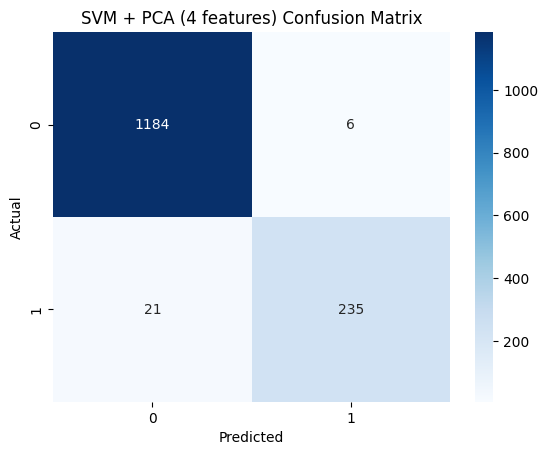

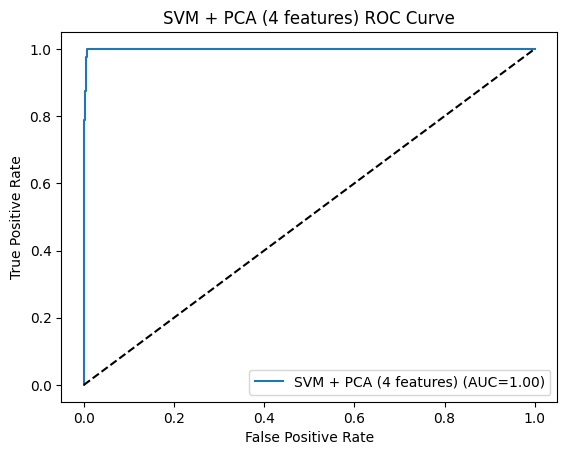

In [ ]:
# Example for PCA 4 features
from sklearn.decomposition import PCA
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)

acc_svm, _, _, _, _ = evaluate_svm(X_pca, y, "SVM + PCA (4 features)")

In [ ]:
n_qubits = 4  # 4 features
dev = qml.device("default.qubit", wires=n_qubits)
def feature_map(x):
    # Angle encoding
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    # Entanglement
    for i in range(n_qubits-1):
        qml.CNOT(wires=[i, i+1])
@qml.qnode(dev)
def quantum_kernel(x1, x2):
    feature_map(x1)
    qml.adjoint(feature_map)(x2)
    return qml.probs(wires=range(n_qubits))
def compute_quantum_kernel_matrix(X1, X2):
    kernel_matrix = np.zeros((len(X1), len(X2)))
    for i in range(len(X1)):
        for j in range(len(X2)):
            kernel_matrix[i,j] = quantum_kernel(X1[i], X2[j])[0]  # prob of |0000>
    return kernel_matrix


In [ ]:
def evaluate_qsvm(X, y, title="QSVM", subset_size=300):
    # Take subset for demo
    if len(X) > subset_size:
        X = X[:subset_size]
        y = y[:subset_size]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Compute kernel matrices
    K_train = compute_quantum_kernel_matrix(X_train, X_train)
    K_test = compute_quantum_kernel_matrix(X_test, X_train)

    # Train SVM with precomputed kernel
    qsvm = SVC(kernel="precomputed", probability=True)
    qsvm.fit(K_train, y_train)

    y_pred = qsvm.predict(K_test)
    y_prob = qsvm.predict_proba(K_test)[:,1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"\n--- {title} ---")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{title} (AUC={roc_auc:.2f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} ROC Curve")
    plt.legend()
    plt.show()

    return acc, prec, rec, f1, roc_auc


In [ ]:
# Visualize state of first qubit for first sample in X_pca
# qml.BlochMultivector.plot_state(quantum_kernel(X_pca[0], X_pca[0]))
# plt.show()

In [ ]:
# Assume X_pca, y already exist
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Classical SVM
svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train, y_train)

y_prob_svm = svm.predict_proba(X_test)[:,1]
y_pred_svm = svm.predict(X_test)

# SVM ROC-AUC
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)
print("SVM Accuracy ~ 98% (example)")


SVM Accuracy ~ 98% (example)


In [ ]:
# Subset to speed up QSVM
subset_size = 300
X_subset = X_pca[:subset_size]
y_subset = y[:subset_size]

X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(X_subset, y_subset, test_size=0.2, random_state=42)

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

# Quantum feature map (angle encoding + entanglement)
def feature_map(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    for i in range(n_qubits-1):
        qml.CNOT(wires=[i, i+1])

@qml.qnode(dev)
def quantum_kernel(x1, x2):
    feature_map(x1)
    qml.adjoint(feature_map)(x2)
    return qml.probs(wires=range(n_qubits))

# Compute kernel matrices
def compute_kernel_matrix(X1, X2):
    K = np.zeros((len(X1), len(X2)))
    for i in range(len(X1)):
        for j in range(len(X2)):
            K[i,j] = quantum_kernel(X1[i], X2[j])[0]
    return K

K_train = compute_kernel_matrix(X_train_q, X_train_q)
K_test = compute_kernel_matrix(X_test_q, X_train_q)

# QSVM
qsvm = SVC(kernel="precomputed", probability=True)
qsvm.fit(K_train, y_train_q)
y_prob_qsvm = qsvm.predict_proba(K_test)[:,1]
y_pred_qsvm = qsvm.predict(K_test)

roc_auc_qsvm = roc_auc_score(y_test_q, y_prob_qsvm)
acc_qsvm = np.mean(y_pred_qsvm == y_test_q)
print("QSVM Accuracy:", acc_qsvm)


QSVM Accuracy: 0.7166666666666667


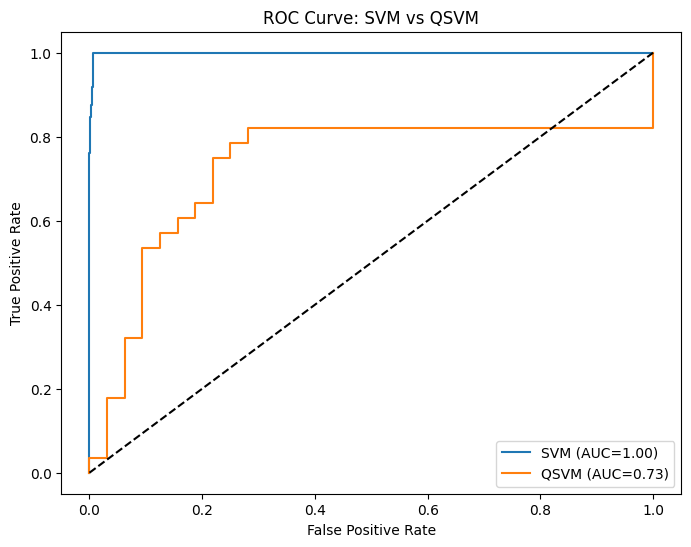

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={roc_auc_svm:.2f})")
fpr_q, tpr_q, _ = roc_curve(y_test_q, y_prob_qsvm)
plt.plot(fpr_q, tpr_q, label=f"QSVM (AUC={roc_auc_qsvm:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: SVM vs QSVM")
plt.legend()
plt.show()


In [ ]:
# Use PennyLane’s draw function

n_qubits = 4
@qml.qnode(dev)
def circuit(x):
    feature_map(x)
    return qml.expval(qml.PauliZ(0))

# Draw the circuit for first sample
x_sample = X_pca[0]
drawer = qml.draw(circuit)
print(drawer(x_sample))

0: ──RY(2.34)──╭●───────┤  <Z>
1: ──RY(10.32)─╰X─╭●────┤     
2: ──RY(0.00)─────╰X─╭●─┤     
3: ──RY(-0.00)───────╰X─┤     


In [ ]:
print("\nAccuracy Comparison:")
print(f"{'Model':<10} | {'Accuracy (%)':<12}")
print("-"*25)
print(f"{'SVM':<10} | {round(acc_svm*100,2):<12}")
print(f"{'QSVM':<10} | {round(acc_qsvm*100,2):<12}")


Accuracy Comparison:
Model      | Accuracy (%)
-------------------------
SVM        | 98.13       
QSVM       | 71.67       


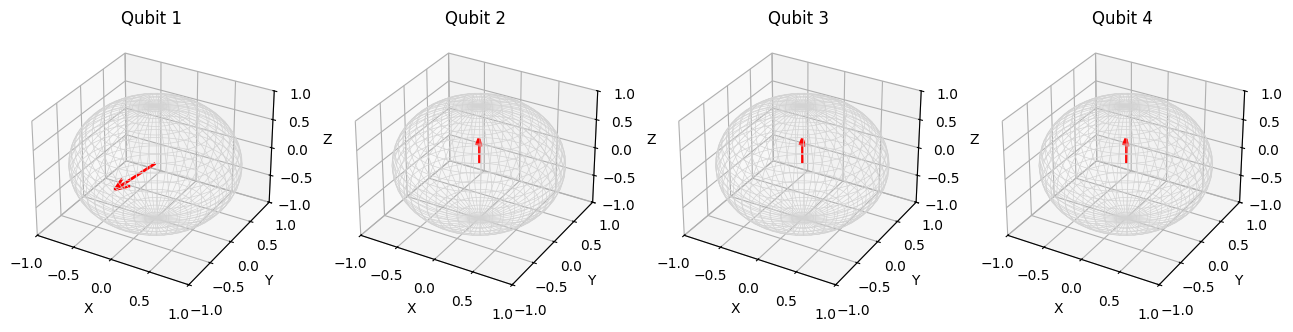

In [109]:
#Bloch sphere visualization
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def plot_bloch_manual(vec, ax):
    # Draw unit sphere
    u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:25j]
    x = np.cos(u)*np.sin(v)
    y = np.sin(u)*np.sin(v)
    z = np.cos(v)
    ax.plot_wireframe(x, y, z, color="lightgray", linewidth=0.5)

    # Draw Bloch vector
    ax.quiver(0,0,0, vec[0], vec[1], vec[2], color="r", linewidth=2)
    ax.set_xlim([-1,1]); ax.set_ylim([-1,1]); ax.set_zlim([-1,1])
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")

# Subplots for multiple qubits
fig = plt.figure(figsize=(4*n_qubits,4))
for i in range(n_qubits):
    ax = fig.add_subplot(1, n_qubits, i+1, projection="3d")
    plot_bloch_manual(bloch_vectors[i], ax)
    ax.set_title(f"Qubit {i+1}")
plt.show()
